<a href="https://colab.research.google.com/github/dJasawat/Guvi_Assignmnets5_AI-Powered-Banking-Support-Fraud-Intelligence-System-using-NLP-RAG/blob/main/AI_Banking_NLP_DataCleaning_and_Processing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Load Required Packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud


In [ ]:
#mount  Google drive
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#Load Raw Data for Cleaning
DIR_PATH = "/content/drive/MyDrive/Guvi Projects/Guvi_Project5_NLP+RAG BankingSystem/"

In [ ]:
#Load Raw Data for Cleaning

df = pd.read_csv(DIR_PATH + "RawData/01_support_tickets.csv")


In [ ]:
rawData = df[["query_text", "category", "sentiment"]]
#display(rawData.head(20))
print("Categories : ", rawData["category"].unique())
print("Sentiments : ", rawData["sentiment"].unique())

Categories :  ['KYC' 'Fraud/Unauthorized' 'Loan' 'Account Access']
Sentiments :  ['Neutral' 'Frustrated' 'Anxious' 'Angry' 'Confused' 'Urgent']


In [ ]:
print(rawData["category"].value_counts())
print(rawData["sentiment"].value_counts())

category
Account Access        258
Loan                  256
KYC                   244
Fraud/Unauthorized    242
Name: count, dtype: int64
sentiment
Confused      206
Frustrated    194
Neutral       186
Anxious       173
Urgent        138
Angry         103
Name: count, dtype: int64


In [ ]:
rawData.duplicated().sum()

np.int64(171)

In [ ]:
#Data Preprocessing
import pickle
from sklearn.preprocessing import LabelEncoder

le_category = LabelEncoder()

rawData['category'] = le_category.fit_transform(rawData['category'])

le_sentiment = LabelEncoder()
rawData['sentiment'] = le_sentiment.fit_transform(rawData['sentiment'])




/tmp/ipykernel_7789/1591901355.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rawData['category'] = le_category.fit_transform(rawData['category'])
/tmp/ipykernel_7789/1591901355.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rawData['sentiment'] = le_sentiment.fit_transform(rawData['sentiment'])


In [ ]:
# Save category Label Encoder
with open(DIR_PATH + "models/category_label_encoder.pkl", "wb") as f:
    pickle.dump(le_category, f)

# Save sentiment label Encoder
with open(DIR_PATH + "models/sentiment_label_encoder.pkl", "wb") as f:
    pickle.dump(le_sentiment, f)


In [ ]:
rawData['category'].value_counts()

,count
category,
0,258
3,256
2,244
1,242


In [ ]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('wordnet')

stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [ ]:
def clean_data(text):
    # Remove special characters and digits
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    # Convert to lowercase
    text = text.lower()
    # Tokenize the text
    tokens = nltk.word_tokenize(text)
    # Remove stop words
    tokens = [word for word in tokens if word not in stop_words]
    # Lemmatization
    lemmatizer = nltk.WordNetLemmatizer()
    tokens = [lemmatizer.lemmatize(word) for word in tokens]
    return ' '.join(tokens)

In [ ]:
#Clean Data
rawData['cleaned_query_text'] = rawData['query_text'].apply(clean_data)
cleanData = rawData.copy()

/tmp/ipykernel_7789/481531452.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rawData['cleaned_query_text'] = rawData['query_text'].apply(clean_data)


In [ ]:
#Save the cleaned data to a new CSV file
rawData.to_csv(DIR_PATH + "ProcessedData/Cleaned_support_tickets.csv", index=False)

# **Create ML - Model **

In [ ]:
cleanData["category"] = le_category.inverse_transform(cleanData["category"])
cleanData["sentiment"] = le_sentiment.inverse_transform(cleanData["sentiment"])

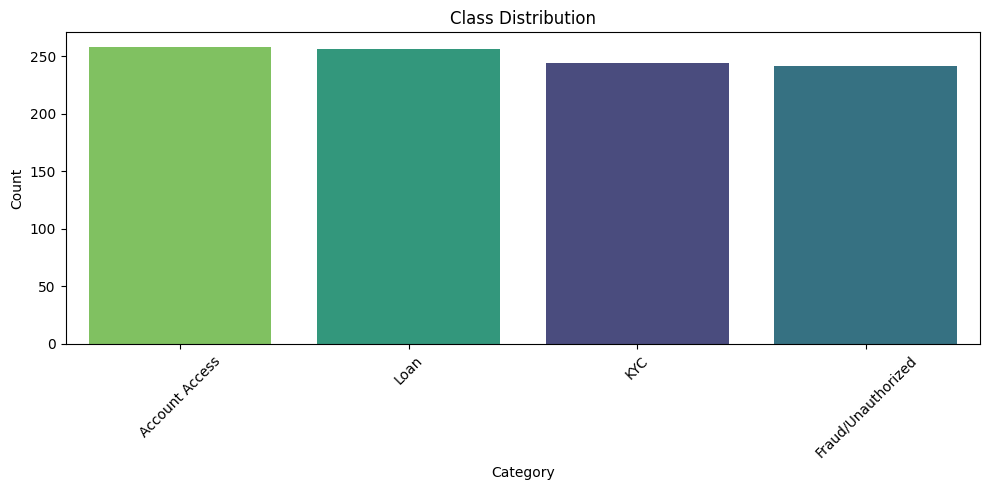

In [ ]:
plt.figure(figsize=(10,5))
sns.countplot(data=cleanData, x='category', order=cleanData['category'].value_counts().index,hue = "category", palette='viridis')
plt.xticks(rotation=45)
plt.title("Class Distribution")
plt.xlabel("Category")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [ ]:
#Word Count per Query
rawData['word_count'] = rawData['cleaned_query_text'].apply(lambda x: len(x.split()))
rawData['word_count'].describe()

/tmp/ipykernel_7789/210792676.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rawData['word_count'] = rawData['cleaned_query_text'].apply(lambda x: len(x.split()))


,word_count
count,1000.000000
mean,7.941000
std,2.083233
min,3.000000
25%,6.000000
50%,8.000000
75%,9.250000
max,13.000000


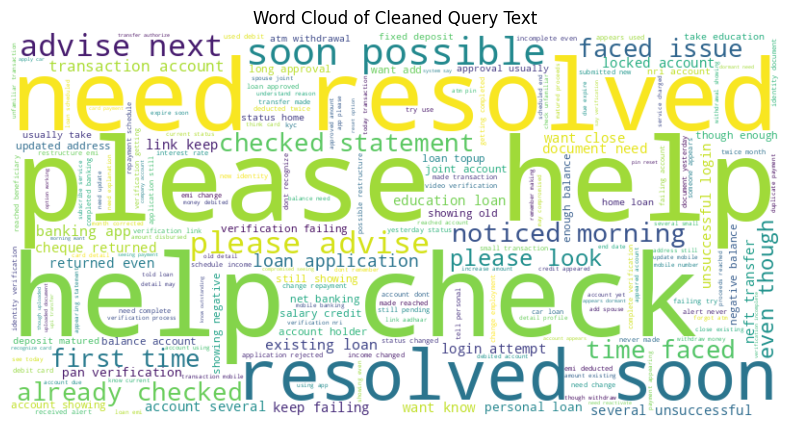

In [ ]:
#Generate a word cloud for the cleaned query text and display it
all_words = ' '.join([text for text in cleanData['cleaned_query_text']])

wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_words)
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud of Cleaned Query Text")
plt.show()

In [ ]:
#generate word cloud for KYC category
kyc_words = ' '.join(cleanData[rawData['category'] == 'KYC']['cleaned_query_text'])
kyc_wordcloud = WordCloud(width=800, height=400, background_color='white', max_words=100).generate(kyc_words)
plt.figure(figsize=(10, 5))
plt.imshow(kyc_wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud of KYC Category")
plt.show()

ValueError: We need at least 1 word to plot a word cloud, got 0.

# **TF-IDF Vectorization and Model Training**


---



In [ ]:
#TF- IDF Vectorization and Model Training

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
#from sklearn import BertClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

In [ ]:
def get_tuned_models():
    """
    Returns a dictionary of machine learning models with predefined hyperparameters.
    """
    tuned_models = {
        "Logistic Regression": LogisticRegression(random_state=42, solver='liblinear', max_iter=200),
        "LinearSVC": LinearSVC(random_state=42, C=0.5, max_iter=1000),
        "MultinomialNB": MultinomialNB(alpha=0.1), # Alpha is a smoothing parameter
        "Random Forest": RandomForestClassifier(random_state=42, n_estimators=100, max_depth=10, min_samples_leaf=5),
        # BertClassifier is not a standard sklearn module and its integration for hyperparameter tuning
        # would require a specific library (e.g., HuggingFace transformers) and different tuning strategies.
        # It's commented out to avoid errors unless a proper implementation is provided.
        # "BertClassifier": BertClassifier()
    }
    return tuned_models

# **Train and evaluate Category**

In [ ]:
#Split the data into training and testing sets
# Split data for Intent Classification
x_train, x_test, y_train, y_test = train_test_split(cleanData['cleaned_query_text'], cleanData['category'], stratify=cleanData['category'], test_size=0.2, random_state=42)
tfidf_vectorizer_Category = TfidfVectorizer(max_features=2000,ngram_range=(1,2))
x_train_tfidf = tfidf_vectorizer_Category.fit_transform(x_train)

In [ ]:
# save sentiment vectorizer in drive
with open(DIR_PATH + "models/tfidf_vectorizer_Category.pkl", "wb") as f:
    pickle.dump(tfidf_vectorizer_Category, f)

In [ ]:
def train_evaluate_Category_model(tuned_models, x_train, x_test, y_train, y_test):
    """
    Trains each model in the dictionary and returns evaluation results.
    """
    results = []
    trained_models = {}

    for model_name, model in tuned_models.items():
        # Training
        model.fit(x_train, y_train)

        # Predictions
        y_train_pred = model.predict(x_train)
        y_test_pred = model.predict(x_test)

        # Metrics
        train_accuracy = accuracy_score(y_train, y_train_pred)
        test_accuracy = accuracy_score(y_test, y_test_pred)
        # Fix: Set output_dict=True to return a dictionary instead of a string
        report = classification_report(y_test, y_test_pred, output_dict=True)

        # Store trained models
        trained_models[model_name] = model

        results.append({
            'Model': model_name,
            'Train Accuracy': train_accuracy,
            'Test Accuracy' : test_accuracy,
            'precision': report.get('weighted avg', {}).get('precision', 0),
            'recall': report.get('weighted avg', {}).get('recall', 0),
            'f1-score': report.get('weighted avg', {}).get('f1-score', 0)
        })

        # Code tocheck if model predicting all cxatagory or not
        print("\nModel:", model_name)

        print("Actual classes:")
        print(sorted(y_test.unique()))

        print("Predicted classes:")
        print(sorted(set(y_train_pred)))

        print("Missing predicted classes:")
        print(set(y_test.unique()) - set(y_train_pred))
      # end of the code
    return results,trained_models

# 1. Vectorize the test set using the fitted vectorizer
x_test_tfidf = tfidf_vectorizer_Category.transform(x_test)


# 2. Get the tuned models
tuned_models = get_tuned_models()

# 3. Train and Evaluate - Catgory Classification
evaluation_data_Intent,models = train_evaluate_Category_model(tuned_models, x_train_tfidf, x_test_tfidf, y_train, y_test)


# 5. Display Results in a DataFrame
category_results_df = pd.DataFrame(evaluation_data_Intent)
category_results_df.set_index('Model', inplace=True)

#display("Category Classification Model\n"+ category_results_df)
print("Category Classification Model")
display(category_results_df.sort_values(by='f1-score', ascending=False))

#save bestModel in  drive
bestModelName = category_results_df.sort_values(
                                by='f1-score',  ascending=False).index[0]


bestModel   = models[bestModelName]

bestModelName = "Category_BestModel_" + bestModelName
print(bestModelName)

with open(DIR_PATH + "models/"+bestModelName+".pkl", "wb") as f:
    pickle.dump(bestModel, f)



Model: Logistic Regression
Actual classes:
['Account Access', 'Fraud/Unauthorized', 'KYC', 'Loan']
Predicted classes:
['Account Access', 'Fraud/Unauthorized', 'KYC', 'Loan']
Missing predicted classes:
set()

Model: LinearSVC
Actual classes:
['Account Access', 'Fraud/Unauthorized', 'KYC', 'Loan']
Predicted classes:
['Account Access', 'Fraud/Unauthorized', 'KYC', 'Loan']
Missing predicted classes:
set()

Model: MultinomialNB
Actual classes:
['Account Access', 'Fraud/Unauthorized', 'KYC', 'Loan']
Predicted classes:
[np.str_('Account Access'), np.str_('Fraud/Unauthorized'), np.str_('KYC'), np.str_('Loan')]
Missing predicted classes:
set()

Model: Random Forest
Actual classes:
['Account Access', 'Fraud/Unauthorized', 'KYC', 'Loan']
Predicted classes:
['Account Access', 'Fraud/Unauthorized', 'KYC', 'Loan']
Missing predicted classes:
set()
Category Classification Model


,Train Accuracy,Test Accuracy,precision,recall,f1-score
Model,,,,,
Logistic Regression,1.00000,1.00,1.000000,1.00,1.000000
LinearSVC,1.00000,1.00,1.000000,1.00,1.000000
MultinomialNB,1.00000,1.00,1.000000,1.00,1.000000
Random Forest,0.98375,0.99,0.990096,0.99,0.989998


Category_BestModel_Logistic Regression


In [ ]:
print("Number of features:", tfidf_vectorizer_Category.get_feature_names_out().shape[0])
print(tfidf_vectorizer_Category.vocabulary_)

Number of features: 824
{'account': np.int64(4), 'restricted': np.int64(586), 'pending': np.int64(501), 'verification': np.int64(767), 'account restricted': np.int64(20), 'restricted pending': np.int64(587), 'pending verification': np.int64(508), 'someone': np.int64(636), 'used': np.int64(758), 'credit': np.int64(176), 'card': np.int64(118), 'online': np.int64(473), 'without': np.int64(804), 'knowledge': np.int64(347), 'someone used': np.int64(638), 'used credit': np.int64(759), 'credit card': np.int64(178), 'card online': np.int64(122), 'online without': np.int64(475), 'without knowledge': np.int64(806), 'identity': np.int64(316), 'getting': np.int64(290), 'completed': np.int64(161), 'banking': np.int64(99), 'app': np.int64(47), 'need': np.int64(440), 'resolved': np.int64(584), 'soon': np.int64(639), 'possible': np.int64(521), 'identity verification': np.int64(318), 'verification getting': np.int64(772), 'getting completed': np.int64(291), 'completed banking': np.int64(162), 'banking 

Train and evalute Sentiment Classification Model

In [ ]:
#Split the data into training and testing sets
# Split data for sentiment Classification
x_train_sentiment, x_test_sentiment, y_train_sentiment, y_test_sentiment = train_test_split(cleanData['cleaned_query_text'], cleanData['sentiment'], stratify=cleanData['sentiment'], test_size=0.2, random_state=42)
tfidf_vectorizer_sentiment = TfidfVectorizer(max_features=2000,ngram_range=(1,2))
x_train_sentiment_tfidf = tfidf_vectorizer_sentiment.fit_transform(x_train_sentiment)

In [ ]:
# save sentiment vectorizer in drive
with open(DIR_PATH + "models/tfidf_vectorizer_sentiment.pkl", "wb") as f:
    pickle.dump(tfidf_vectorizer_sentiment, f)


In [ ]:
print("Number of features:", tfidf_vectorizer_sentiment.get_feature_names_out().shape[0])
print(x_train_sentiment_tfidf.shape)

Number of features: 825
(800, 825)


In [ ]:
# Train and evaluate Sentiment Model

def train_evaluate_Sentiment_model(tuned_models, x_train, x_test, y_train, y_test):
    """
    Trains each model in the dictionary and returns evaluation results.
    """
    results = []
    trained_models = {}

    for model_name, model in tuned_models.items():
        # Training
        model.fit(x_train, y_train)

        # Predictions
        y_train_pred = model.predict(x_train)
        y_test_pred = model.predict(x_test)

        # Metrics
        train_accuracy = accuracy_score(y_train, y_train_pred)
        test_accuracy = accuracy_score(y_test, y_test_pred)
        # Fix: Set output_dict=True to return a dictionary instead of a string
        report = classification_report(y_test, y_test_pred, output_dict=True)


        # Store trained models
        trained_models[model_name] = model

        results.append({
            'Model': model_name,
            'Train Accuracy': train_accuracy,
            'precision': report.get('weighted avg', {}).get('precision', 0),
            'recall': report.get('weighted avg', {}).get('recall', 0),
            'f1-score': report.get('weighted avg', {}).get('f1-score', 0)
        })

        # Code to check if model predicting all categories
        print("\nModel:", model_name)
        print("Actual classes:", sorted(y_test.unique()))
        print("Predicted classes:", sorted(set(y_train_pred)))
        print("Missing predicted classes:", set(y_test.unique()) - set(y_train_pred))

    return results, trained_models

# 1. Vectorize the test set using the fitted vectorizer
x_test_sentiment_tfidf = tfidf_vectorizer_sentiment.transform(x_test_sentiment)

# 2. Get the tuned models
tuned_models = get_tuned_models()

# 4. Train and Evaluate - Sentiment Classification
evaluation_data_sentiment, trained_models_sentiment = train_evaluate_Sentiment_model(
    tuned_models, x_train_sentiment_tfidf,
    x_test_sentiment_tfidf, y_train_sentiment,
    y_test_sentiment
)

# 5 Display sentiment classification in dataframe
sentiment_results_df = pd.DataFrame(evaluation_data_sentiment)
sentiment_results_df.set_index('Model', inplace=True)

print("Sentiment Classification Model")
display(sentiment_results_df.sort_values(by='f1-score', ascending=False))

# save bestModel in drive
bestModelName = sentiment_results_df.sort_values(by='f1-score', ascending=False).index[0]

# FIX: Reference trained_models_sentiment instead of the old 'models' variable
bestModel = trained_models_sentiment[bestModelName]

full_save_name = "Sentiment_BestModel_" + bestModelName
print(f"Saving: {full_save_name}")

with open(DIR_PATH + "models/" + full_save_name + ".pkl", "wb") as f:
    pickle.dump(bestModel, f)


Model: Logistic Regression
Actual classes: ['Angry', 'Anxious', 'Confused', 'Frustrated', 'Neutral', 'Urgent']
Predicted classes: ['Angry', 'Anxious', 'Confused', 'Frustrated', 'Neutral', 'Urgent']
Missing predicted classes: set()

Model: LinearSVC
Actual classes: ['Angry', 'Anxious', 'Confused', 'Frustrated', 'Neutral', 'Urgent']
Predicted classes: ['Angry', 'Anxious', 'Confused', 'Frustrated', 'Neutral', 'Urgent']
Missing predicted classes: set()

Model: MultinomialNB
Actual classes: ['Angry', 'Anxious', 'Confused', 'Frustrated', 'Neutral', 'Urgent']
Predicted classes: [np.str_('Angry'), np.str_('Anxious'), np.str_('Confused'), np.str_('Frustrated'), np.str_('Neutral'), np.str_('Urgent')]
Missing predicted classes: set()

Model: Random Forest
Actual classes: ['Angry', 'Anxious', 'Confused', 'Frustrated', 'Neutral', 'Urgent']
Predicted classes: ['Angry', 'Anxious', 'Confused', 'Frustrated', 'Neutral', 'Urgent']
Missing predicted classes: set()
Sentiment Classification Model


/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


,Train Accuracy,precision,recall,f1-score
Model,,,,
Logistic Regression,0.43750,0.230912,0.255,0.237647
MultinomialNB,0.45000,0.239146,0.240,0.235185
LinearSVC,0.50375,0.219140,0.225,0.218985
Random Forest,0.41875,0.208072,0.235,0.199333


Saving: Sentiment_BestModel_Logistic Regression


In [ ]:
#DONt USE
# Save all trained models to the specified directory in Google Drive
import os

# Ensure the models directory exists
models_dir = DIR_PATH + "models/"
if not os.path.exists(models_dir):
    os.makedirs(models_dir)

# Save each model in the tuned_models dictionary
for model_name, model in tuned_models.items():
    # Sanitize file name by replacing spaces with underscores
    file_name = f"{model_name.lower().replace(' ', '_')}_model.pkl"
    file_path = models_dir + file_name

    with open(file_path, 'wb') as f:
        pickle.dump(model, f)

    print(f"Successfully saved {model_name} to {file_path}")

Successfully saved Logistic Regression to /content/drive/MyDrive/Guvi Projects/Guvi_Project5_NLP+RAG BankingSystem/models/logistic_regression_model.pkl
Successfully saved LinearSVC to /content/drive/MyDrive/Guvi Projects/Guvi_Project5_NLP+RAG BankingSystem/models/linearsvc_model.pkl
Successfully saved MultinomialNB to /content/drive/MyDrive/Guvi Projects/Guvi_Project5_NLP+RAG BankingSystem/models/multinomialnb_model.pkl
Successfully saved Random Forest to /content/drive/MyDrive/Guvi Projects/Guvi_Project5_NLP+RAG BankingSystem/models/random_forest_model.pkl


In [ ]:
!pip install gradio -q

import gradio as gr
import os
import pickle


def predict_intent(user_query):

    # =========================================================
    # 1. PREPROCESS INPUT
    # =========================================================
    cleaned_text = clean_data(user_query)


    # =========================================================
    # 2. CATEGORY PREDICTION
    # =========================================================

    # Load Category TF-IDF Vectorizer
    category_vectorizer_path = os.path.join(
        DIR_PATH,
        "models",
        "tfidf_vectorizer_Category.pkl"
    )

    with open(category_vectorizer_path, "rb") as f:
        tfidf_vectorizer_category = pickle.load(f)

    # Transform query
    category_vectorized_text = (
        tfidf_vectorizer_category.transform([cleaned_text])
    )

    # Load Best Category Model
    category_model_path = os.path.join(
        DIR_PATH,
        "models",
        "Category_BestModel_Logistic Regression.pkl"
    )

    with open(category_model_path, "rb") as f:
        category_model = pickle.load(f)


    # Predict Category
    category_prediction = category_model.predict(
        category_vectorized_text
    )[0]


    # Category probabilities
    category_probabilities = category_model.predict_proba(
        category_vectorized_text
    )[0]
    # Get category labels

    # Encoded category labels from the model
    category_labels= category_model.classes_

    category_conf_dict = {
        category_labels[i]: float(category_probabilities[i])
        for i in range(len(category_labels))
    }


    # =========================================================
    # 3. SENTIMENT PREDICTION
    # =========================================================

    # Load Sentiment TF-IDF Vectorizer
    sentiment_vectorizer_path = os.path.join(
        DIR_PATH,
        "models",
        "tfidf_vectorizer_sentiment.pkl"
    )

    with open(sentiment_vectorizer_path, "rb") as f:
        tfidf_vectorizer_sentiment = pickle.load(f)

    # Transform query
    sentiment_vectorized_text = (
        tfidf_vectorizer_sentiment.transform([cleaned_text])
    )

    # Load Best Sentiment Model
    sentiment_model_path = os.path.join(
        DIR_PATH,
        "models",
        "Sentiment_BestModel_Logistic Regression.pkl"
    )

    with open(sentiment_model_path, "rb") as f:
        sentiment_model = pickle.load(f)

    # Predict Sentiment
    sentiment_prediction = sentiment_model.predict(
        sentiment_vectorized_text
    )[0]

    # Sentiment probabilities
    sentiment_probabilities = sentiment_model.predict_proba(
        sentiment_vectorized_text
    )[0]

    sentiment_labels = sentiment_model.classes_

    sentiment_conf_dict = {
        sentiment_labels[i]: float(sentiment_probabilities[i])
        for i in range(len(sentiment_labels))
    }


    # =========================================================
    # 4. RETURN BOTH RESULTS
    # =========================================================

    return (
        category_prediction,
        category_conf_dict,
        sentiment_prediction,
        sentiment_conf_dict
    )


# =============================================================
# GRADIO INTERFACE
# =============================================================

interface = gr.Interface(

    fn=predict_intent,

    inputs=gr.Textbox(
        lines=3,
        placeholder="Enter your banking query here...",
        label="Support Ticket Text"
    ),

    outputs=[
        gr.Textbox(
            label="Predicted Category"
        ),

        gr.Label(
            label="Category Confidence"
        ),

        gr.Textbox(
            label="Predicted Sentiment"
        ),

        gr.Label(
            label="Sentiment Confidence"
        )
    ],

    title="Banking Support Classifier",

    description=(
        "Predict the category and sentiment of a banking "
        "support query."
    ),

    examples=[
        ["I see a transaction of 500 I didn't make"],
        ["How do I update my KYC documents?"],
        ["My education loan status is still pending."],
        ["I can't log into my net banking account."]
    ]
)


# =============================================================
# LAUNCH
# =============================================================

interface.launch(
    debug=True,
    share=True
)

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://3f7d812f260260b51a.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://3f7d812f260260b51a.gradio.live
